# Task: Your First Artificial Neural Network

**Level:** Easy | **Topic:** Introduction to Artificial Neural Networks (ANN) & Deep Learning
\
By the end of this task you should be able to:
- Explain what a neuron, a layer, and an activation function are
- Build a simple `Sequential` ANN in Keras
- Train a model and read a training curve
- Evaluate a model on unseen (test) data


## 1. A 60-Second Refresher

An **Artificial Neural Network (ANN)** is made of layers of connected "neurons":

- **Input layer** – receives the features (e.g. pixel values, columns of a table)
- **Hidden layer(s)** – learn patterns by combining inputs with weights + an
  **activation function** (e.g. ReLU) that adds non-linearity
- **Output layer** – produces the final prediction (e.g. a class probability
  using **Sigmoid** for binary classification)

Training = the network makes a prediction → compares it to the true answer using a
**loss function** → adjusts its weights using **backpropagation** + an **optimizer**
(e.g. Adam) → repeats for several **epochs**.

That's it — let's build one!


## 2. Setup

Run the cell below to import everything you'll need.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 3. The Dataset

We'll use the **Breast Cancer Wisconsin** dataset (built into scikit-learn).
It's a simple binary classification problem: given measurements of a tumor,
predict whether it is **malignant (0)** or **benign (1)**.


In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape of X:", X.shape)
print("Class distribution:\n", y.value_counts())
X.head()


Shape of X: (569, 30)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### TODO 3.1 — Train/test split

Split `X` and `y` into training and test sets.
- Use `test_size=0.2`
- Use `random_state=42`


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

print("X_train shape:", X_train.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X_train shape: (455, 30)
Train shape: (455, 30)
Test shape: (114, 30)


### TODO 3.2 — Scale the features

Neural networks train much better when input features are on a similar scale.
Use `StandardScaler` to fit on the **training** data and transform both
train and test sets.


In [ ]:
# TODO: fit a StandardScaler on X_train, then transform X_train and X_test
scaler = StandardScaler()
X_train_scaled =  scaler.fit_transform(X_train)
X_test_scaled =    scaler.fit_transform(X_test)


## 4. Build the ANN

### TODO 4.1 — Define the architecture

Build a `Sequential` model with:
1. A `Dense` hidden layer with **16 units** and **ReLU** activation
   (set `input_shape=(X_train.shape[1],)` on this first layer)
2. A second `Dense` hidden layer with **8 units** and **ReLU** activation
3. An output `Dense` layer with **1 unit** and **Sigmoid** activation
   (Sigmoid because this is binary classification)


In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

### TODO 4.2 — Compile the model

Compile the model with:
- optimizer: `"adam"`
- loss: `"binary_crossentropy"` (correct choice for binary classification)
- metrics: `["accuracy"]`


In [ ]:
# TODO: compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 5. Train the Model

### TODO 5.1 — Fit the model

Train for **30 epochs**, with `validation_split=0.2` and `batch_size=16`.
Store the result in a variable called `history` — you'll use it in the next step.


In [ ]:
# TODO: train the model and store the result in `history`
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    validation_split=0.2,
    batch_size=16
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7582 - loss: 0.5117 - val_accuracy: 0.8132 - val_loss: 0.4507
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8764 - loss: 0.3907 - val_accuracy: 0.8791 - val_loss: 0.3470
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9313 - loss: 0.2919 - val_accuracy: 0.8901 - val_loss: 0.2587
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9560 - loss: 0.2094 - val_accuracy: 0.9341 - val_loss: 0.2030
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9670 - loss: 0.1610 - val_accuracy: 0.9451 - val_loss: 0.1717
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9670 - loss: 0.1338 - val_accuracy: 0.9670 - val_loss: 0.1548
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9753 - loss: 0.1159 - val_accuracy: 0.9560 - val_loss: 0.1443
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.1023 - val_accuracy: 0.9780 - val_loss

### 5.2 — Plot the training curves

This cell is already complete — just run it once `history` exists.

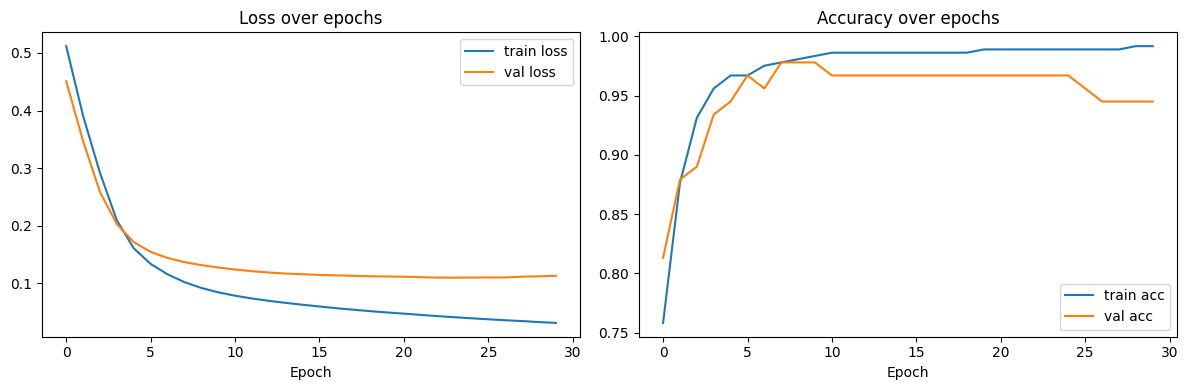

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train acc')
axes[1].plot(history.history['val_accuracy'], label='val acc')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluate on the Test Set

### TODO 6.1 — Evaluate

Use `model.evaluate()` on the **scaled test set** and print the test accuracy.


In [ ]:
# TODO: evaluate the model on X_test_scaled / y_test
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9649 - loss: 0.0822
Test accuracy: 0.9649


## 7. Reflection Questions

Answer briefly in the markdown cell below (2–3 sentences each):

1. What would happen to training if you removed the `StandardScaler` step?
2. Why did we use **Sigmoid** in the output layer instead of **ReLU**?
3. Looking at your loss/accuracy plot — is the model overfitting, underfitting,
   or fitting well? How can you tell?


_Your answers here:_

1.  **What would happen if you removed the `StandardScaler`?** Training would likely be slower and less stable. Features with bigger numbers would unfairly dominate the learning, making it harder for the model to find the best solution.
2.  **Why Sigmoid for the output, not ReLU?** We use Sigmoid for binary classification because it gives us a probability (a number between 0 and 1). ReLU doesn't do that; it's better for hidden layers where we just need non-linearity.
3.  **Is the model overfitting, underfitting, or fitting well?** It looks like the model is fitting well! Both the training and validation performance (loss going down, accuracy going up) are moving together nicely, suggesting it's learning effectively without memorizing the training data too much.